# ___Summary of hOUwie model fits___
-------------------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.6.0 (2026-04-24 ucrt)"


In [2]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("corHMM")
    library("OUwie")
    library("ggplot2")
})

In [1]:
packageVersion("OUwie")

[1] '3.2'

In [3]:
packageVersion("corHMM")

[1] '2.8'

In [2]:
# the OUMA and OUMVA model issues have been fixed in OUwie versions 3.00 and up, see the below page for details
# https://thej022214.github.io/OUwie/articles/calculationUpdate.html

In [5]:
#--------------------------
# helper functions
#--------------------------


read_all_rds <- function(dirpath, cd, strip, rm_underscores = TRUE) {
    # dirpath = path to the directory containing the .Rds files
    # cd = character dependent or independent models, these are expected to contain "CD" or "CID" in their names
    # strip = the regex pattern to strip out of the file names when naming objects, can be a plain string as well
    # rm_underscores - strip all the underscores in the object name

    fnames <- list.files(dirpath) # all the files in the specified dir
    if(cd) fnames <- fnames[grep(pattern = "CD", fnames)]
    else fnames <- fnames[grep(pattern = "CID", fnames)] # cherry pick CD or CID models, given their names contain "CD" or "CID" to distinguish them
    # print(fnames)

    paths <- paste0(dirpath, fnames) # relative paths for all the Rds files
    stopifnot(length(fnames)==length(paths))

    # remove the unnecessary parts of the file names to create the model names and also remove all the underscores
    mnames <- fnames |> gsub(pattern = ".Rds", replacement = '') |> gsub(pattern = strip, replacement = '') |> gsub(pattern = ifelse(rm_underscores, '_', ''), replacement = '')
    stopifnot(length(fnames)==length(mnames))
    stopifnot(length(paths)==length(mnames))

    models <- list()
    for (i in seq_along(mnames)) models[[mnames[i]]] <- readRDS(file = paths[i])
    stopifnot(length(models)==length(mnames))

    models
}


convergence_failures <- function(models, strip='', threshold_diff_aicc=1e5){
    model_table <- OUwie::getModelTable(models, type = "AICc") # model table from the models
    model_names <- row.names(model_table)
    model_names <- gsub(pattern = strip, replacement = '', x = model_names) # strip off the specified pattern from the names
    aiccs <- model_table[, "AICc"] # this becomes a hard requirement of the function, that the input dataframe needs to have a column named "AICc"
    # so the criteria is that the absoulte difference between the AICc of a given model and the highest AICc (worst fit) shouldn't exceed 1e5, else it's considered a convergence failure
    model_names[abs(aiccs - max(aiccs)) >= threshold_diff_aicc]  # with an option provided to pass in a custom difference threshold
}


plot_model_averages <- function(data){
    # the data argument is expected to be the untouched output of the OUwie::getModelAvgParams() function
    stopifnot(is.data.frame(data))
    
    options(repr.plot.width = 15, repr.plot.height = 15)
    par(mfrow = c(2, 2), mar = c(3, 4, 0, 0), mgp = c(2.25, 0.75, 0))

    boxplot(formula = rates ~ tip_state, data = data, xlab = NULL, ylab = "Rates")
    boxplot(formula = alpha ~ tip_state, data = data, xlab = NULL, ylab = expression(alpha))
    boxplot(formula = sigma.sq ~ tip_state, data = data, xlab = NULL, ylab = expression(sigma^2))
    boxplot(formula = theta ~ tip_state, data = data, xlab = NULL, ylab = expression(theta))
}

In [6]:
# find out the AIC and AICc of all the models

# OUwie::getModelAvgParams()
# type - one of AIC, BIC, or AICc for use during evaluation of relative model fit.
# AICc (small sample size corrected AIC) is the best option for datasets with a few number of species.
# force - a boolean indicating whether to force potentially failed model fits to be included in the model averaging.

# look up to see what the BIC stuff is about https://www.rdocumentation.org/packages/AICcmodavg/versions/2.3-4/topics/bictabCustom
# AIC vs BIC https://fiveable.me/bayesian-statistics/unit-11/bayesian-information-criterion/study-guide/o3iS2biLgz7mcyuv

## ___1. 995 species, 5 mycorrhizal states and FRED 3.0___
------------------------------

In [6]:
#---------------
# root diameter
#---------------

rd_995_cd <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/LOG_RD_995SP_100SIMS/", cd = TRUE, strip = "F00679_CD")
rd_995_cid <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/LOG_RD_995SP_100SIMS/", cd = FALSE, strip = "F00679_CID")

In [8]:
OUwie::getModelTable(rd_995_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,27,-837.7815,-222.4381,-610.7957,1731.127,14.5409887,3.748617e-04
ARDOUMA,31,-1240.7399,-224.6911,-1009.8106,2545.540,828.9543658,5.324186e-181
ARDOUMV,31,-875.8786,-222.4858,-648.7782,1815.817,99.2318326,1.525766e-22
ARDOUMVA,35,-1214.4508,-225.2339,-984.6957,2501.529,784.9436965,1.918884e-171
EROUM,8,-1307.4927,-235.9841,-1065.8242,2631.131,914.5458396,1.381341e-199
EROUMA,12,-1254.1331,-235.9806,-1017.0206,2532.584,815.9983010,3.464391e-178
EROUMV,12,-1238.7481,-235.9414,-999.0268,2501.814,785.2283279,1.664339e-171
EROUMVA,16,-1221.0799,-235.9916,-980.3370,2474.716,758.1305515,1.274821e-165
SYMOUM,17,-841.1358,-225.8393,-610.8337,1716.898,0.3124422,4.608511e-01


In [8]:
convergence_failures(models = rd_995_cd)

character(0)

In [9]:
OUwie::getModelTable(rd_995_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,46,-8.660587e+02,-244.8339,-6.175052e+02,1.828679e+03,18253609577,0
ARDOUMA,47,-1.297129e+03,-245.0929,-1.054712e+03,2.693023e+03,18253610441,0
ARDOUMV,47,-1.285349e+03,-244.7591,-1.039078e+03,2.669462e+03,18253610417,0
ARDOUMVA,48,-1.277052e+03,-245.2749,-1.044505e+03,2.655076e+03,18253610403,0
EROUM,8,-8.584728e+02,-236.2650,-6.178687e+02,1.733092e+03,18253609481,0
EROUMA,9,4.294540e+09,-236.6196,-8.320778e+03,-8.589081e+09,9664527211,0
EROUMV,9,-8.728444e+02,-236.0431,-6.322679e+02,1.763872e+03,18253609512,0
EROUMVA,10,9.126804e+09,-242.6438,8.589933e+09,-1.825361e+10,0,1
SYMOUM,26,-8.853430e+02,-248.2156,-1.078624e+03,1.824136e+03,18253609572,0


In [10]:
convergence_failures(models = rd_995_cid) # two failed CID fits

[1] "EROUMA"  "EROUMVA"

In [11]:
capture.output(avg_rd_995_cd <- OUwie::getModelAvgParams(rd_995_cd, type = "AICc", force = FALSE), file = nullfile()) # OUwie::getModelAvgParams spits out a lot of stuff, we don't want that here
capture.output(avg_rd_995_cid <- OUwie::getModelAvgParams(rd_995_cid, type = "AICc", force = FALSE), file = nullfile())

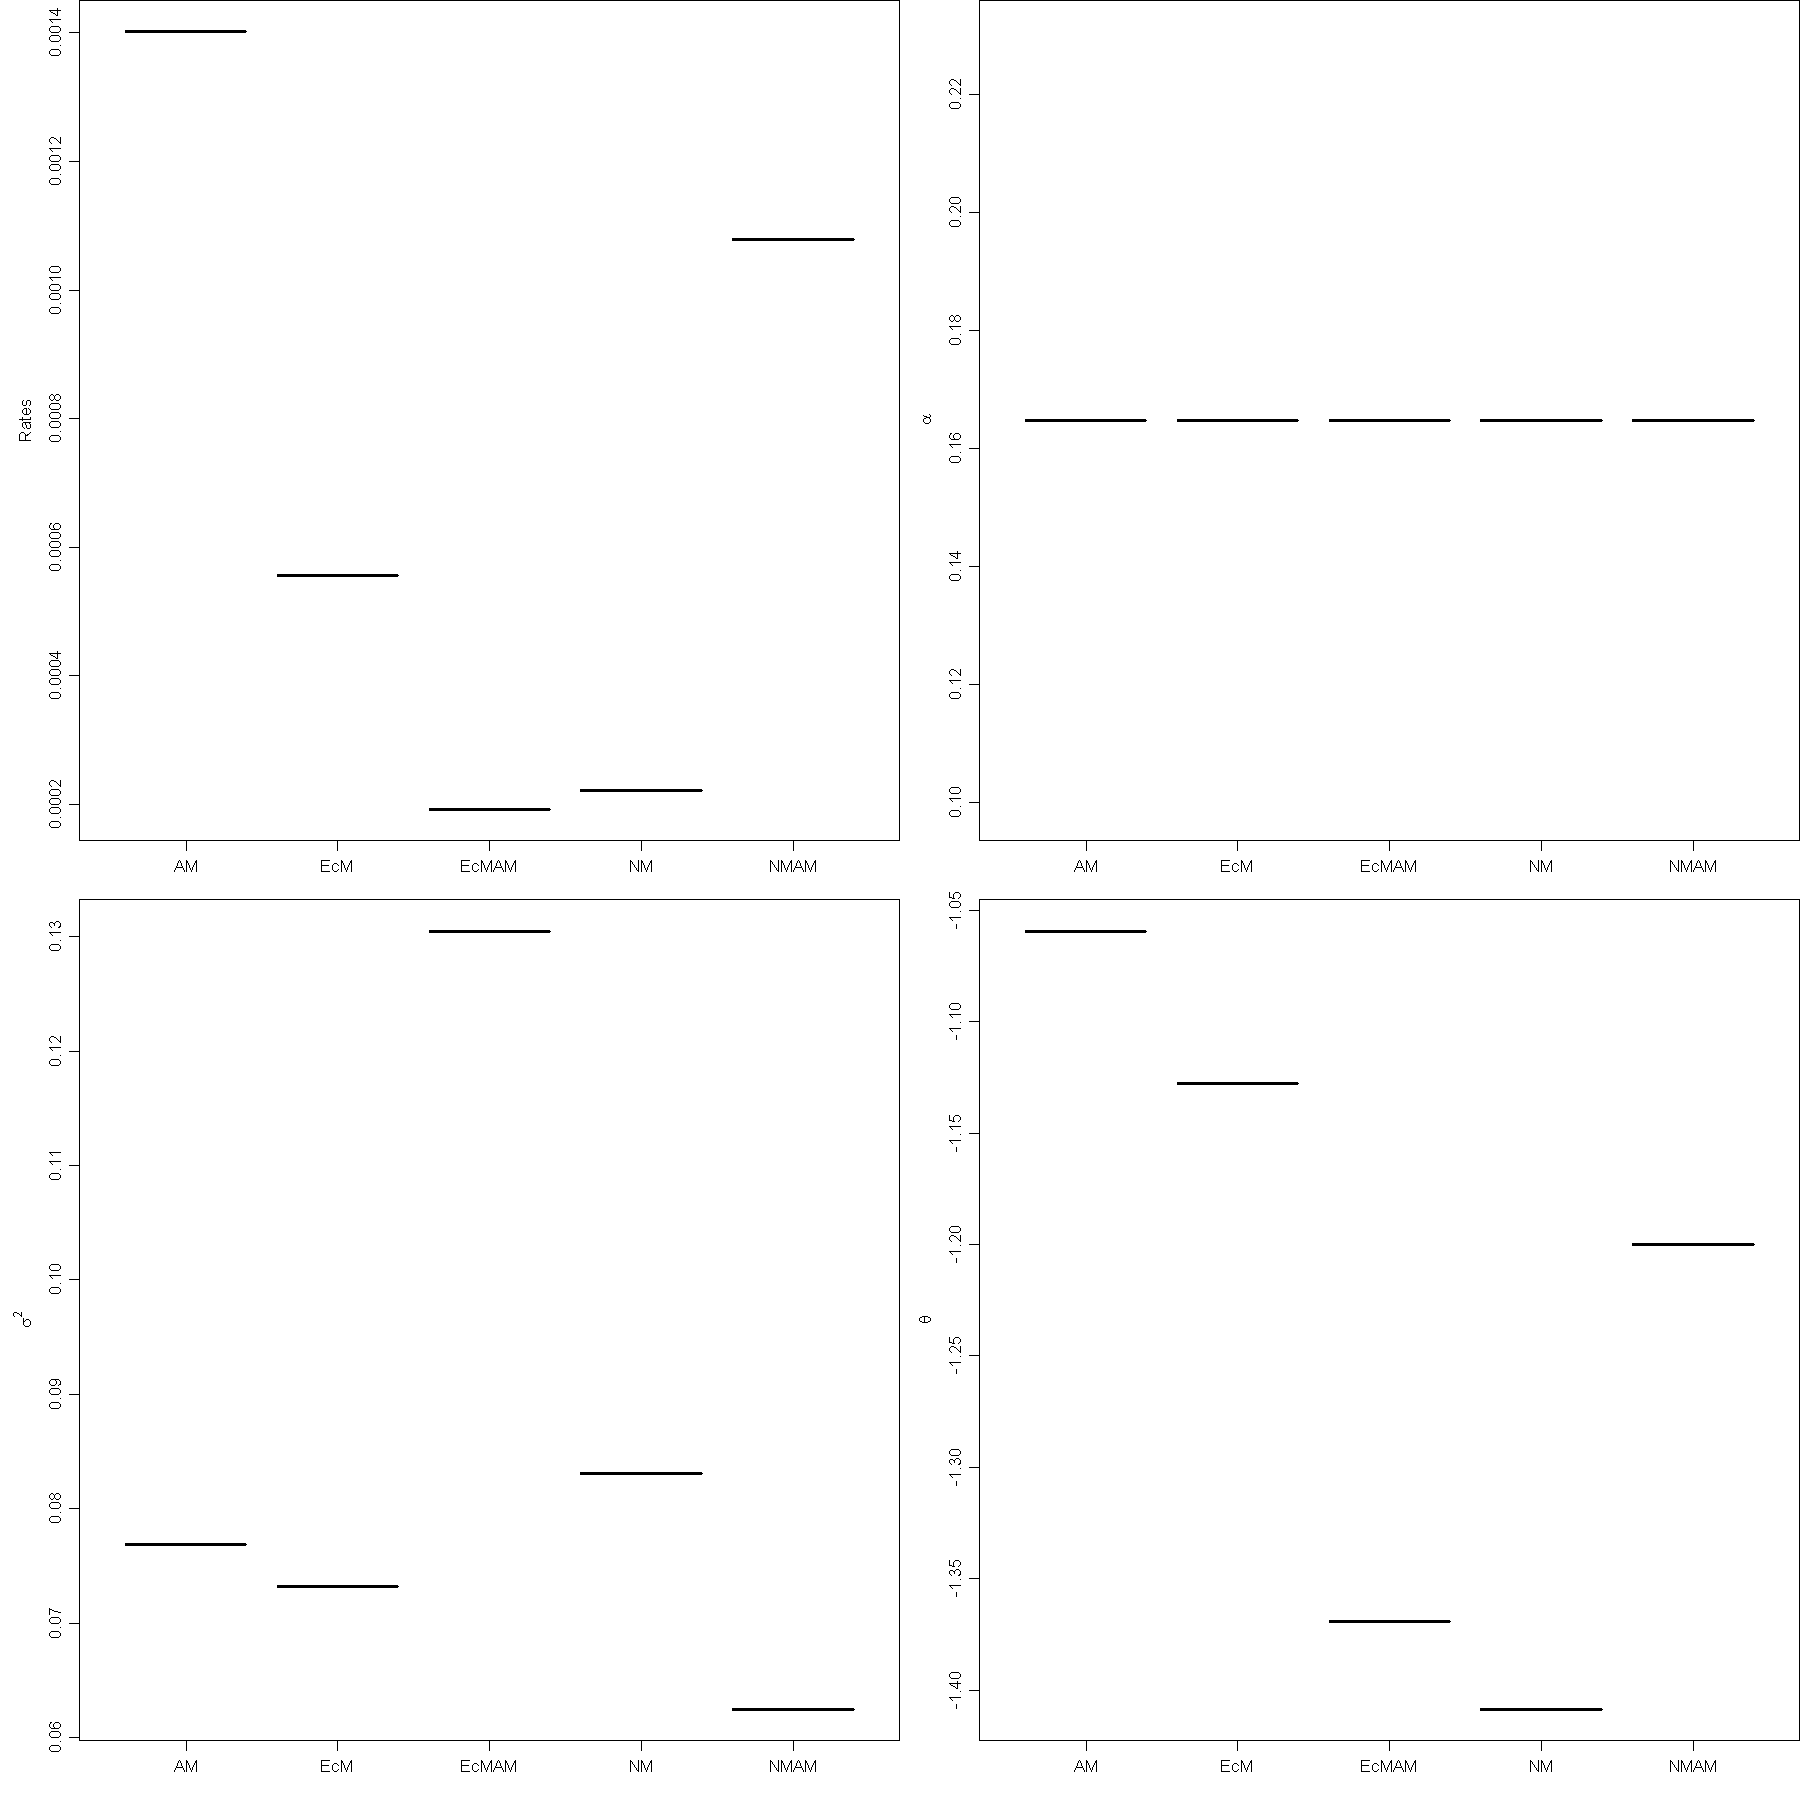

In [7]:
plot_model_averages(data = avg_rd_995_cd) # CD fits

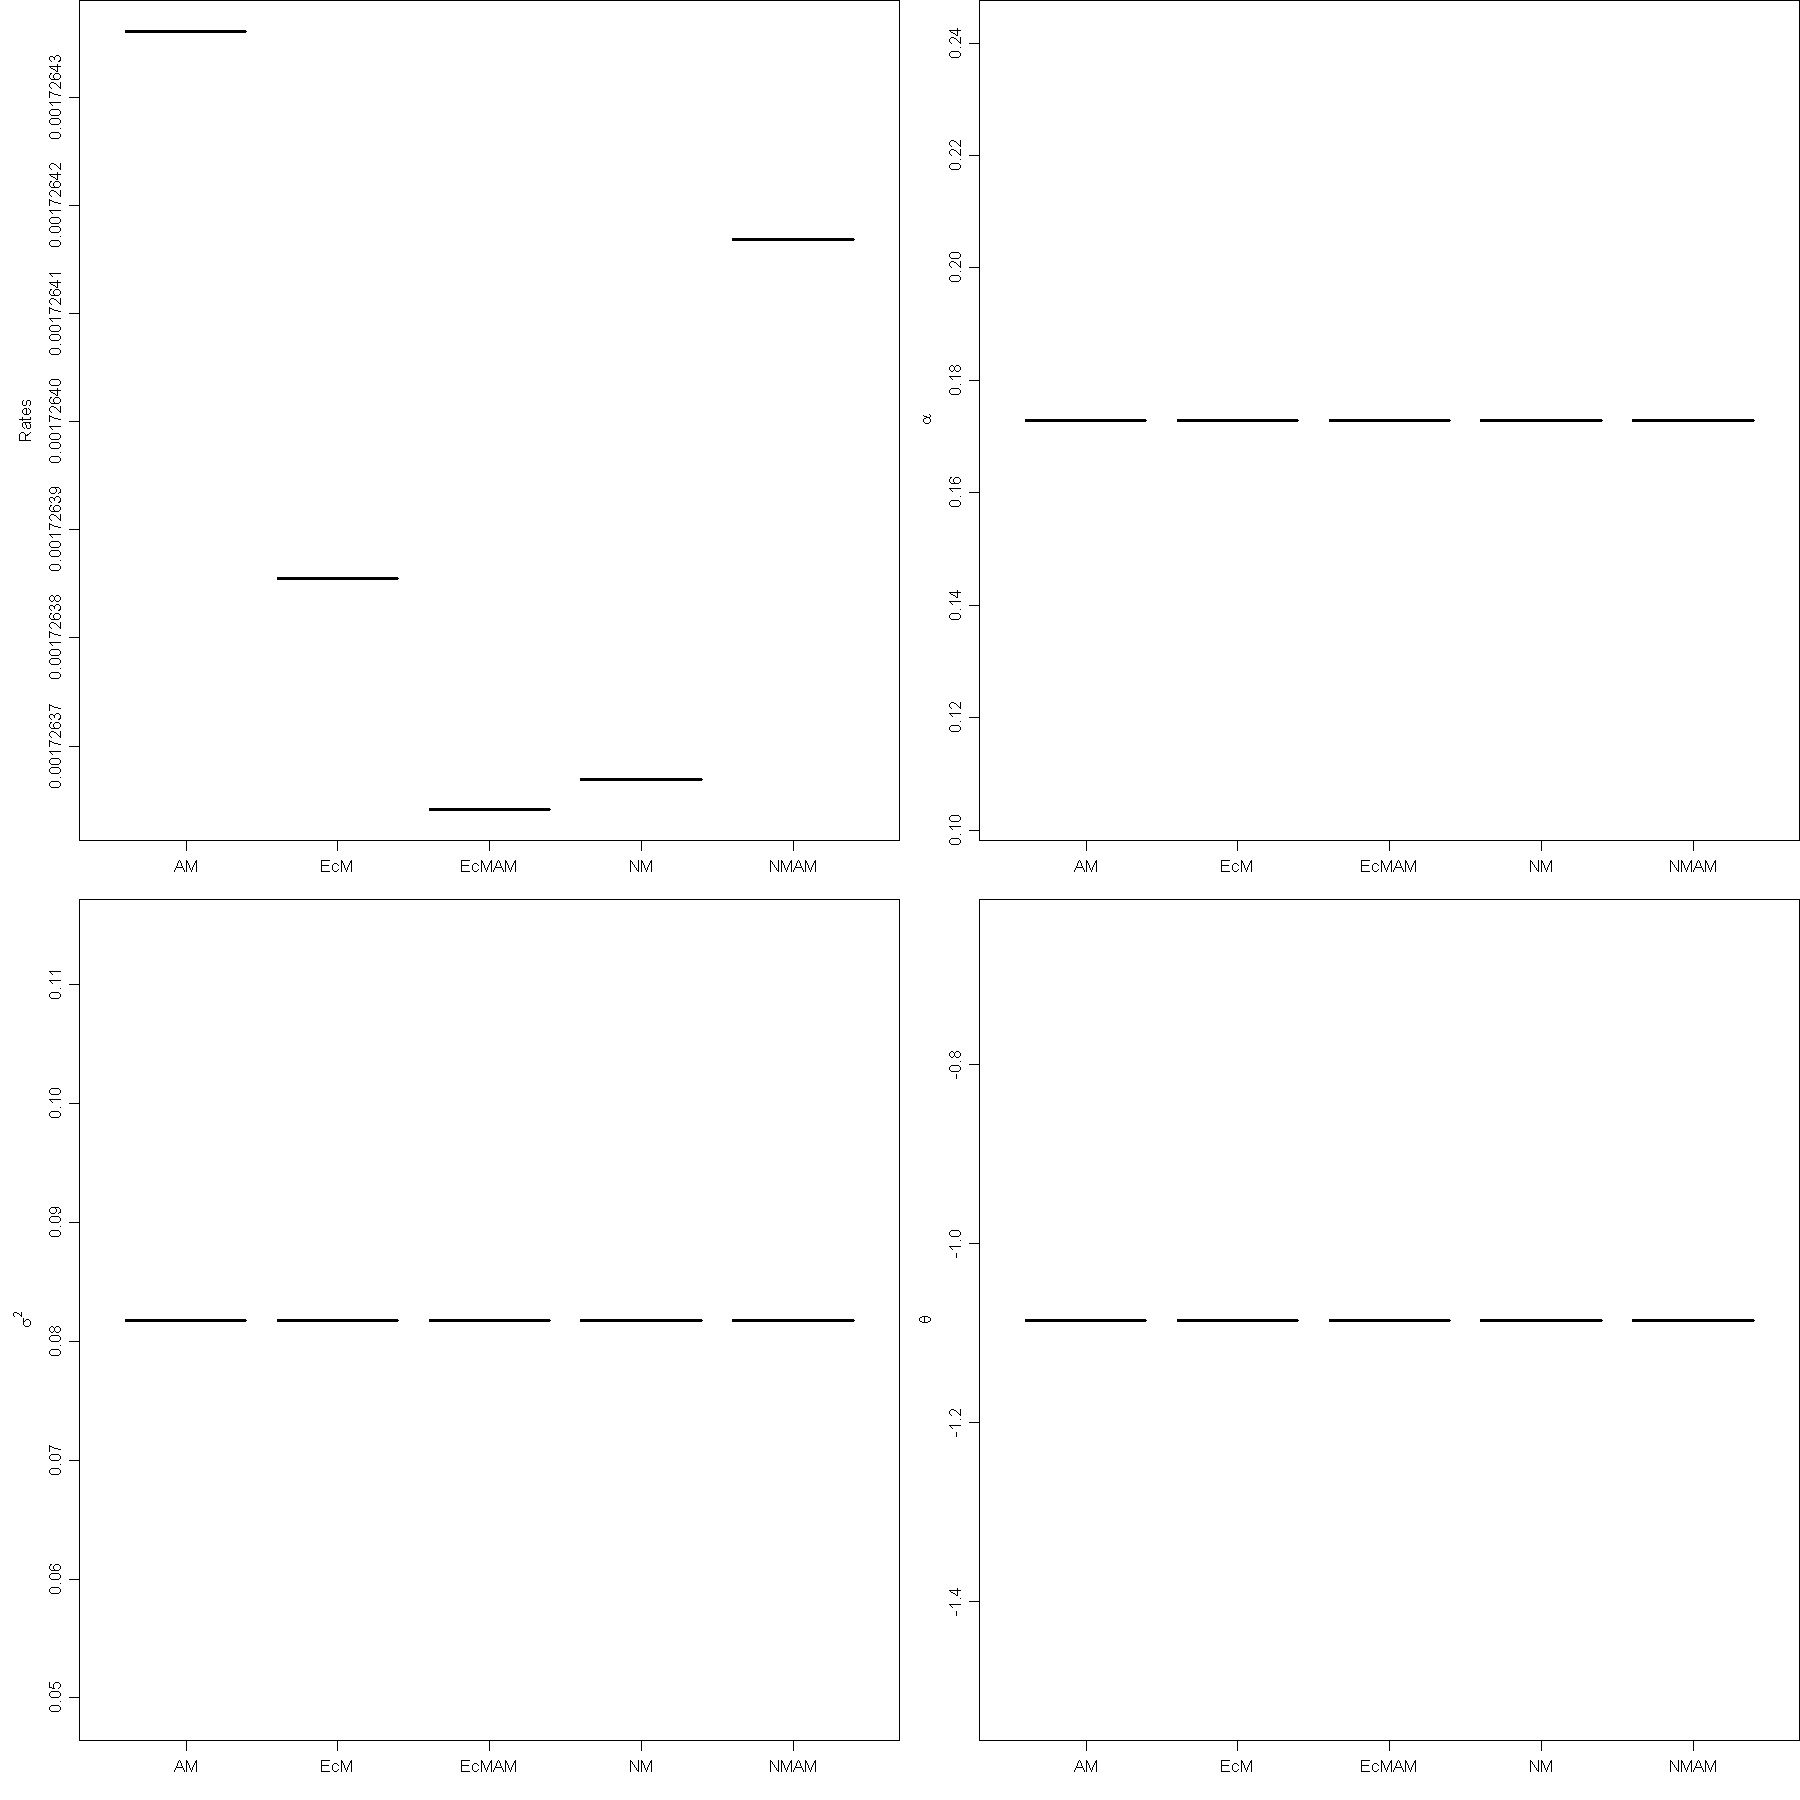

In [8]:
plot_model_averages(data = avg_rd_995_cid) # CID fits

In [12]:
#------------------------
# specific root length
#------------------------

srl_995_cd <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/LOG_SRL_995SP_100SIMS/", cd = TRUE, strip = "F00727_CD")
srl_995_cid <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/LOG_SRL_995SP_100SIMS/", cd = FALSE, strip = "F00727_CID")

In [13]:
OUwie::getModelTable(srl_995_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,27,-1898.815,-222.4386,-1671.813,3853.194,31.503764,8.816617e-08
ARDOUMA,31,-2211.673,-224.2157,-1983.303,4487.406,665.715792,1.690090e-145
ARDOUMV,31,-2221.894,-222.3920,-1995.005,4507.848,686.158003,6.150923e-150
ARDOUMVA,35,-2164.539,-225.2221,-1934.445,4401.705,580.014976,6.880272e-127
EROUM,8,-1904.484,-235.9440,-1664.636,3825.114,3.424010,1.103426e-01
EROUMA,12,-2234.623,-235.9917,-1992.989,4493.565,671.874426,7.772836e-147
EROUMV,12,-1898.686,-235.9516,-1658.743,3821.690,0.000000,6.113043e-01
EROUMVA,16,-2198.069,-236.0035,-1958.364,4428.694,607.004213,9.483473e-133
SYMOUM,17,-1894.319,-225.8475,-1664.442,3823.263,1.573409,2.783531e-01


In [14]:
convergence_failures(srl_995_cd)

character(0)

In [15]:
OUwie::getModelTable(srl_995_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,46,-2.280617e+03,-265.4901,-2025.149,4.657795e+03,17179870052,0
ARDOUMA,47,-2.174983e+03,-262.8171,-2053.463,4.448731e+03,17179869842,0
ARDOUMV,47,-2.249811e+03,-260.8590,-2026.660,4.598387e+03,17179869992,0
ARDOUMVA,48,-2.085369e+03,-268.5176,-1833.000,4.271710e+03,17179869665,0
EROUM,8,-2.265167e+03,-235.9243,-2024.658,4.546480e+03,17179869940,0
EROUMA,9,8.589933e+09,-236.3958,536869234.335,-1.717987e+10,0,1
EROUMV,9,-1.913447e+03,-235.9671,-1673.154,3.845077e+03,17179869239,0
EROUMVA,10,-2.144410e+03,-237.5550,-2013.270,4.309044e+03,17179869703,0
SYMOUM,26,-1.919728e+03,-250.2099,-1734.309,3.892906e+03,17179869287,0


In [16]:
convergence_failures(srl_995_cid) # two failures

[1] "EROUMA"  "SYMOUMA"

In [16]:
capture.output(avg_srl_995_cd <- OUwie::getModelAvgParams(srl_995_cd, type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_srl_995_cid <- OUwie::getModelAvgParams(srl_995_cid, type = "AICc", force = FALSE), file = nullfile())

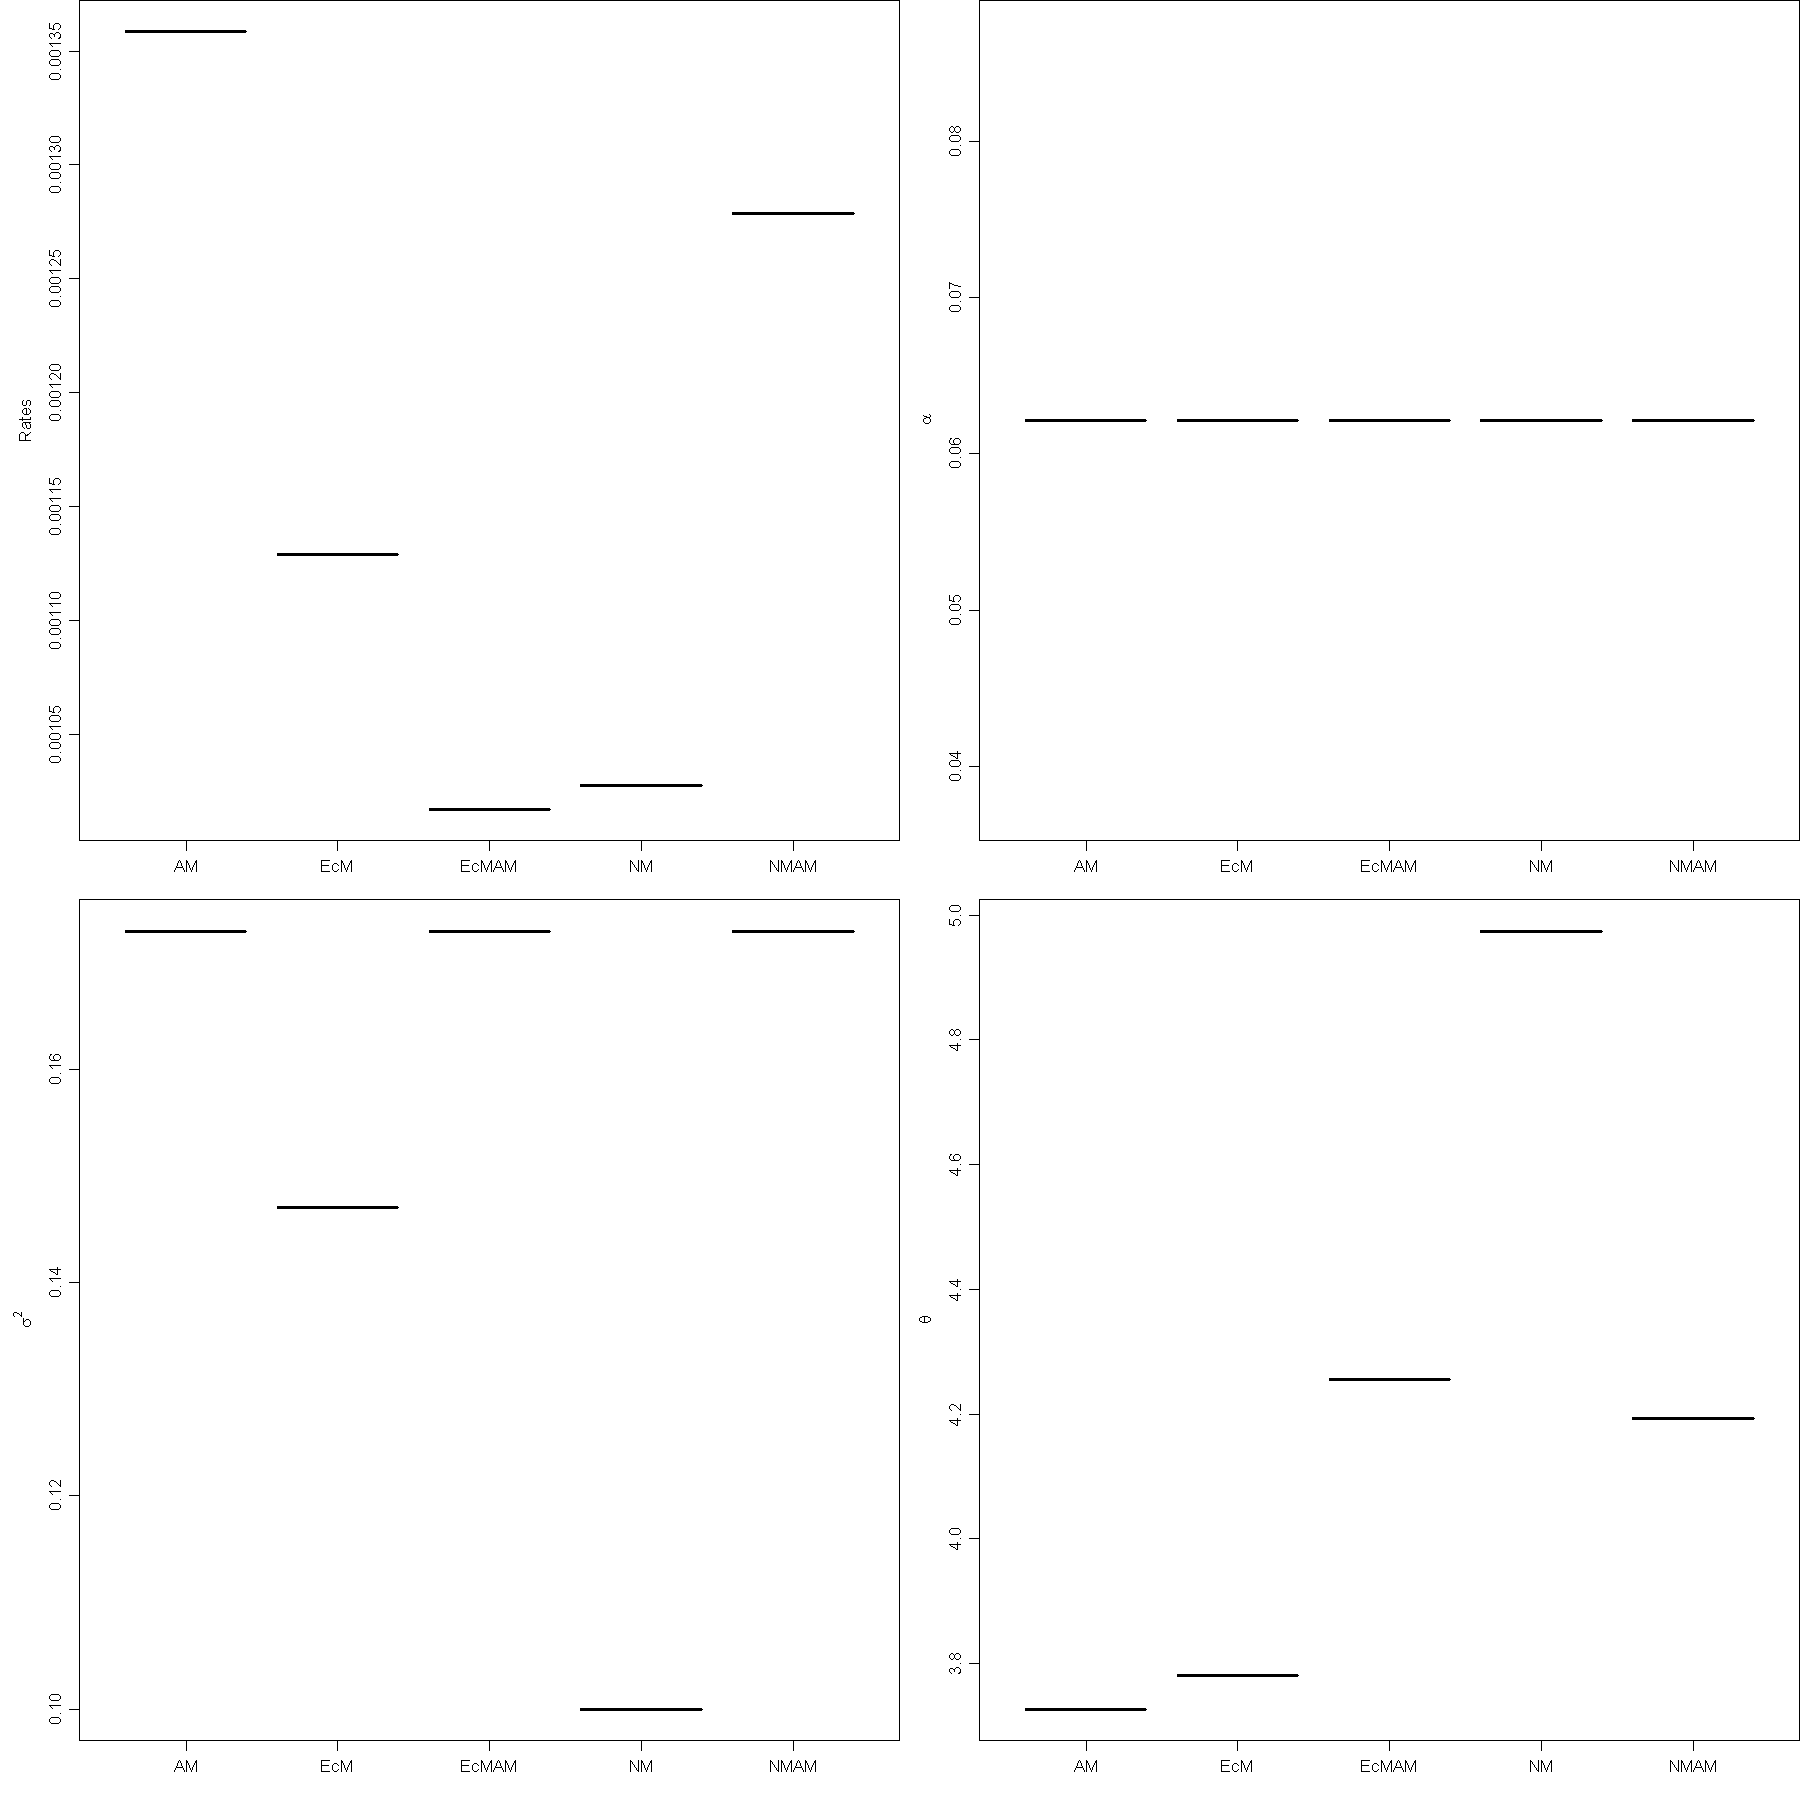

In [17]:
plot_model_averages(data = avg_srl_995_cd)

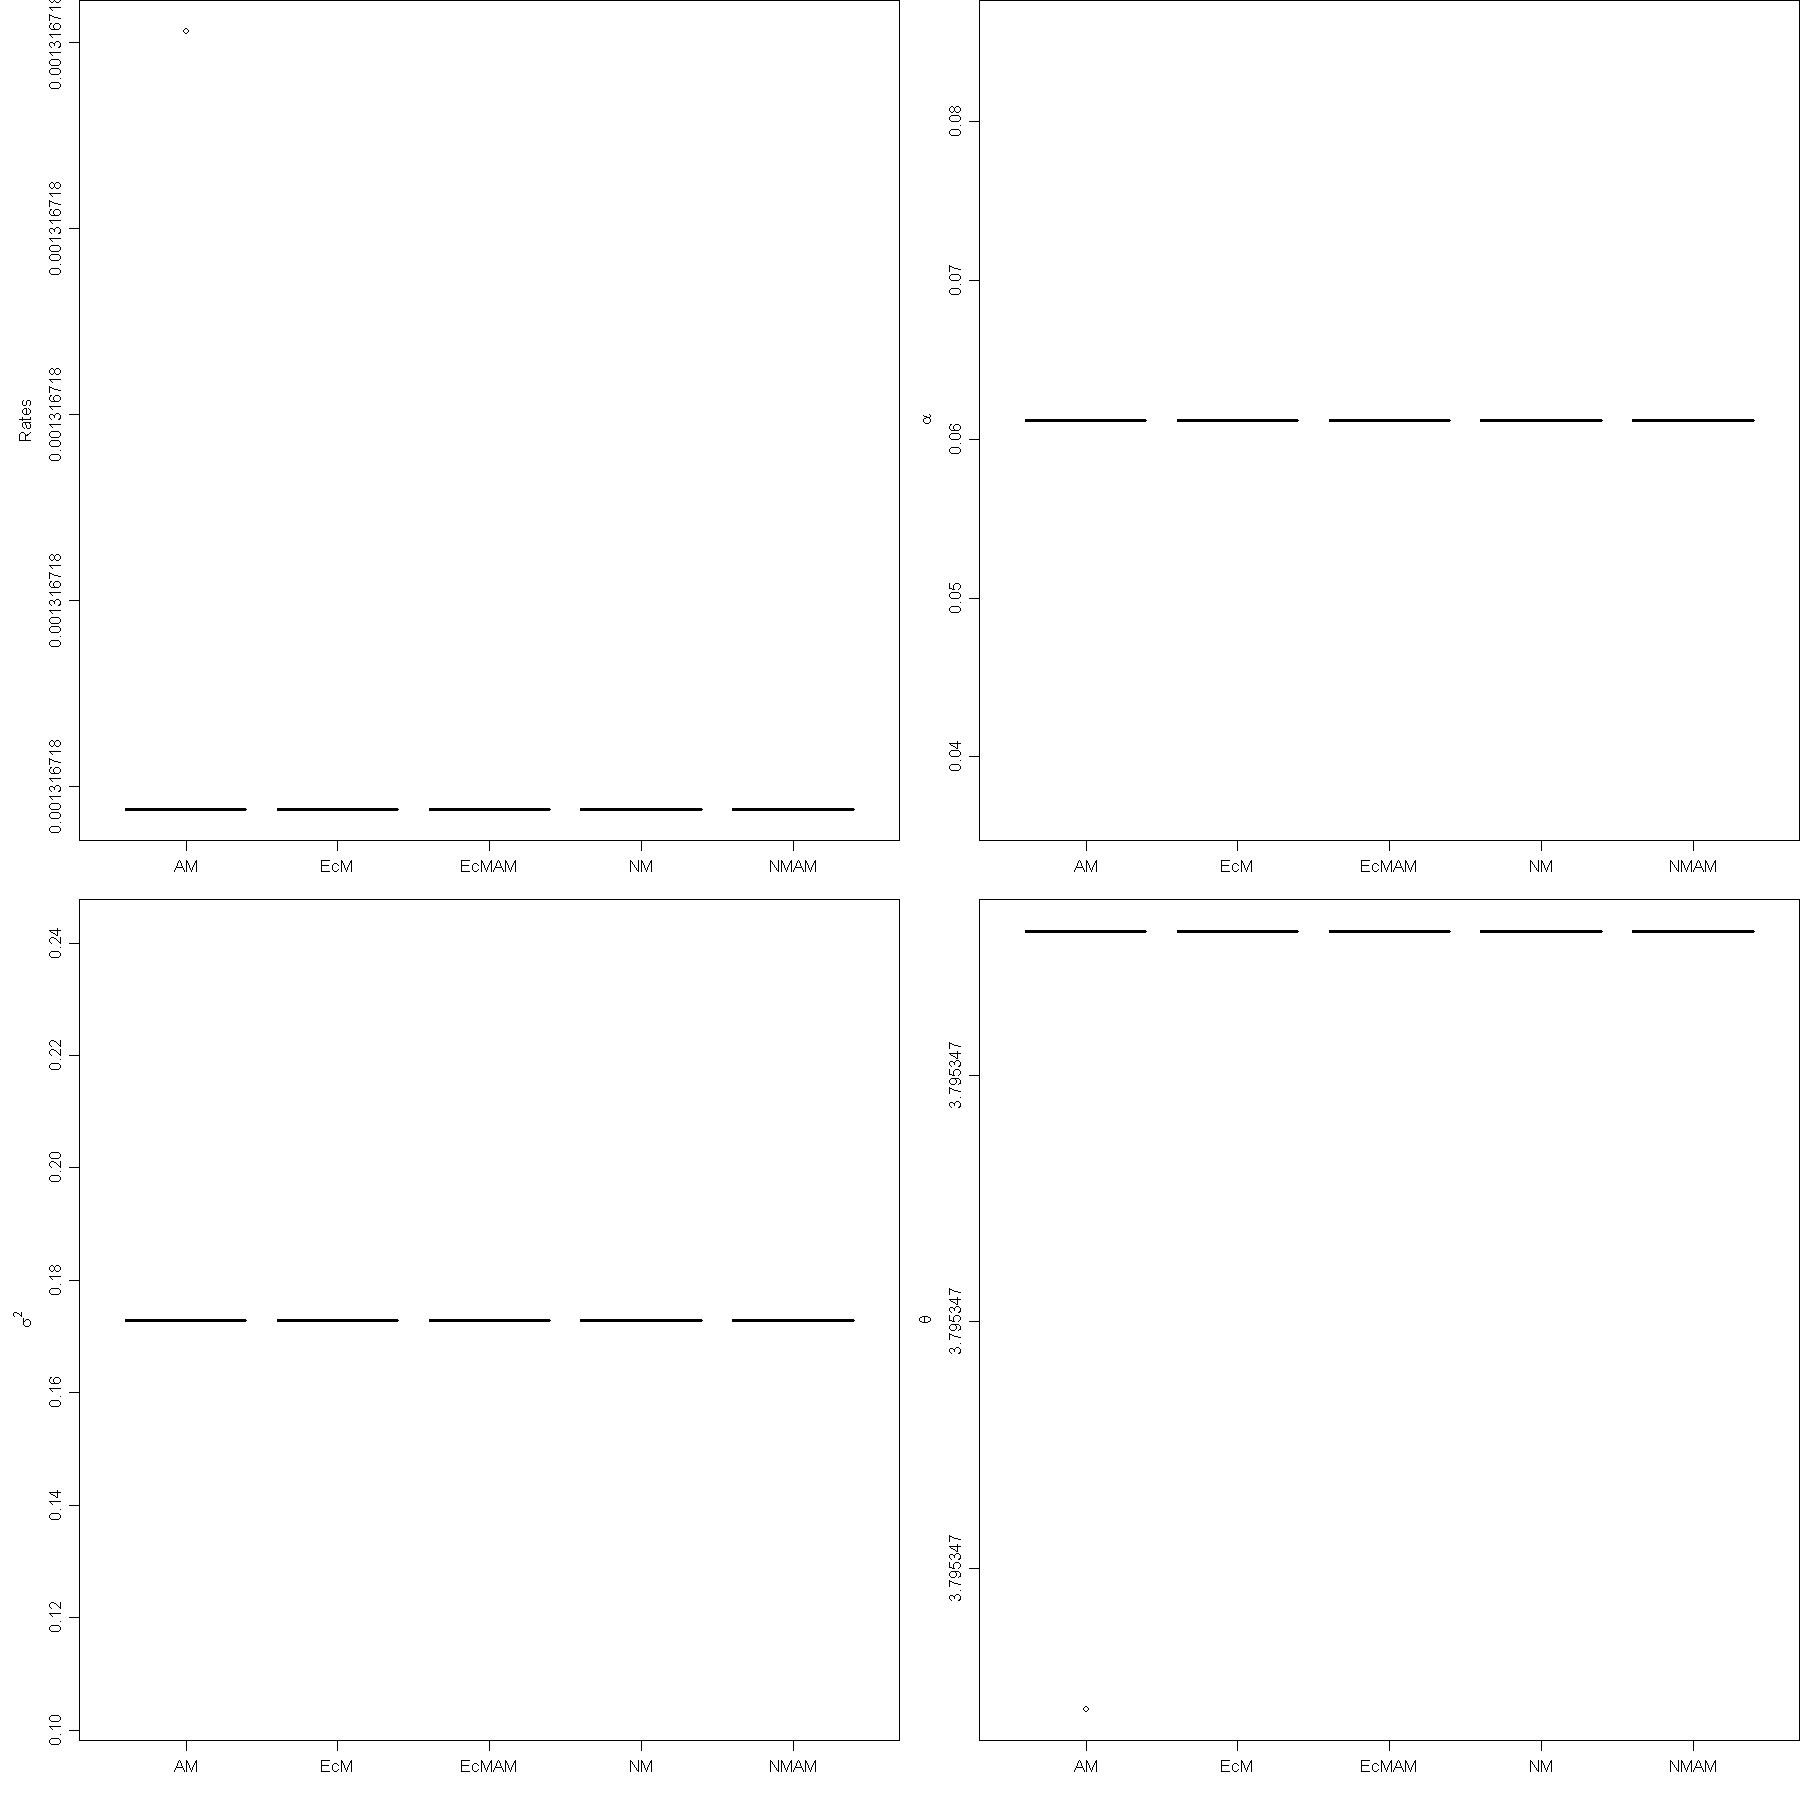

In [18]:
plot_model_averages(data = avg_srl_995_cid)

## ___2. 1301 species, 6 mycorrhizal states and FRED 4.0___
------------------------------

In [17]:
#-----------------
# root diameter
#-----------------

rd_1301_cd <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/rd_1301_100sims/", cd = TRUE, strip = "F00679_CD")
rd_1301_cid <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/rd_1301_100sims/", cd = FALSE, strip = "F00679_CID")

In [18]:
OUwie::getModelTable(rd_1301_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,38,-169625.07,-210.3268,-169406.23,339328.48,301902.03,0
ARDOUMA,43,-27256.80,-227.7743,-37303.47,54602.62,17176.17,0
ARDOUMV,43,-170810.75,-217.6320,-170584.97,341710.51,304284.05,0
ARDOUMVA,48,-186164.82,-227.7870,-5945873.94,372429.41,335002.95,0
EROUM,9,-162911.54,-226.1279,-162677.74,325841.21,288414.76,0
EROUMA,14,-18699.06,-4217.0130,-63987.08,37426.45,0.00,1
EROUMV,14,-163286.96,-225.8778,-163056.57,326602.24,289175.79,0
EROUMVA,19,-48617.21,-1323.5316,-75649.06,97273.01,59846.55,0
SYMOUM,23,-167072.63,-222.9057,-174459.32,334192.13,296765.68,0


In [19]:
convergence_failures(rd_1301_cd) # 5 out of 12 failed???

[1] "ARDOUMA"  "EROUMA"   "EROUMVA"  "SYMOUMA"  "SYMOUMVA"

In [20]:
OUwie::getModelTable(rd_1301_cid, type = "AICc") 

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,66,-125054.19,-258.2815,-133348.54,250247.54,190689.446,0
ARDOUMA,67,-40569.09,-256.2116,-52504.70,81279.57,21721.478,0
ARDOUMV,67,-170910.20,-255.6526,-170702.97,341961.78,282403.687,0
ARDOUMVA,68,-31942.45,-258.2381,-60490.74,64028.52,4470.423,0
EROUM,8,-132590.66,-230.1963,-175342.03,265197.43,205639.328,0
EROUMA,9,-111869.79,-518.4454,-118569.32,223757.72,164199.622,0
EROUMV,9,-124656.54,-320.0560,-133164.15,249331.21,189773.114,0
EROUMVA,10,-136924.07,-244.2835,-144052.83,273868.31,214310.212,0
SYMOUM,36,-124243.17,-249.1996,-130398.55,248560.44,189002.347,0


In [21]:
convergence_failures(rd_1301_cid) # also 5 out of 12 failed???

[1] "ARDOUMA"  "ARDOUMVA" "EROUMA"   "SYMOUMA"  "SYMOUMVA"

In [25]:
capture.output(avg_rd_1301_cd <- OUwie::getModelAvgParams(rd_1301_cd, type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_rd_1301_cid <- OUwie::getModelAvgParams(rd_1301_cid, type = "AICc", force = FALSE), file = nullfile())

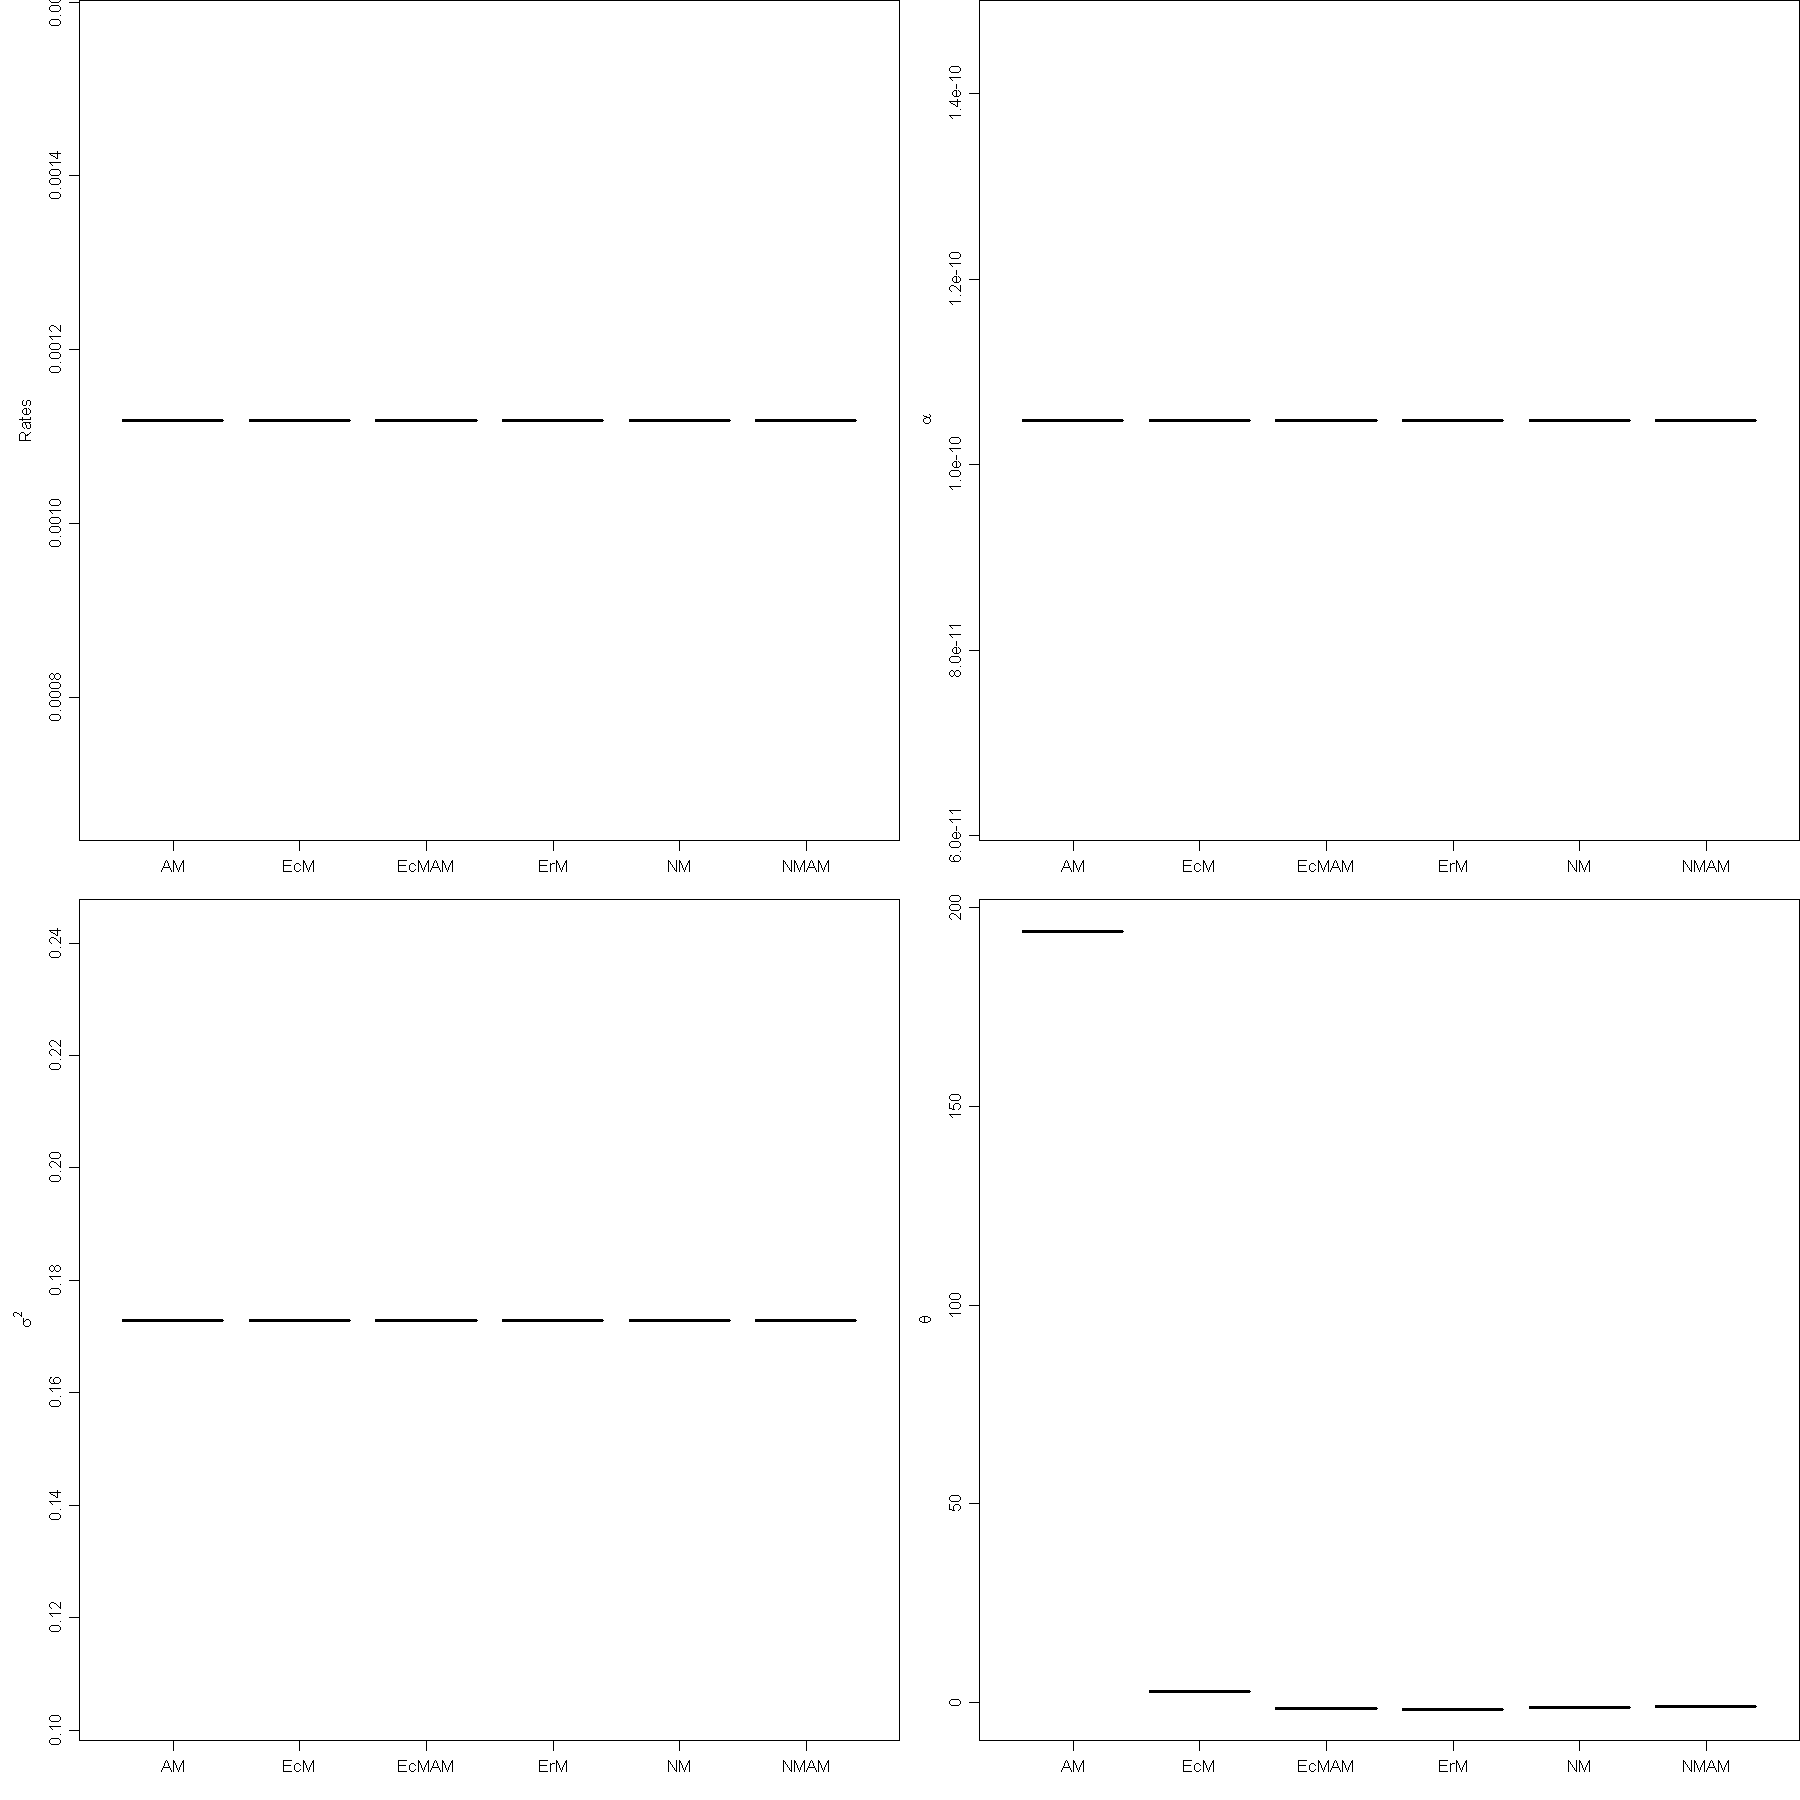

In [27]:
plot_model_averages(data = avg_rd_1301_cd)

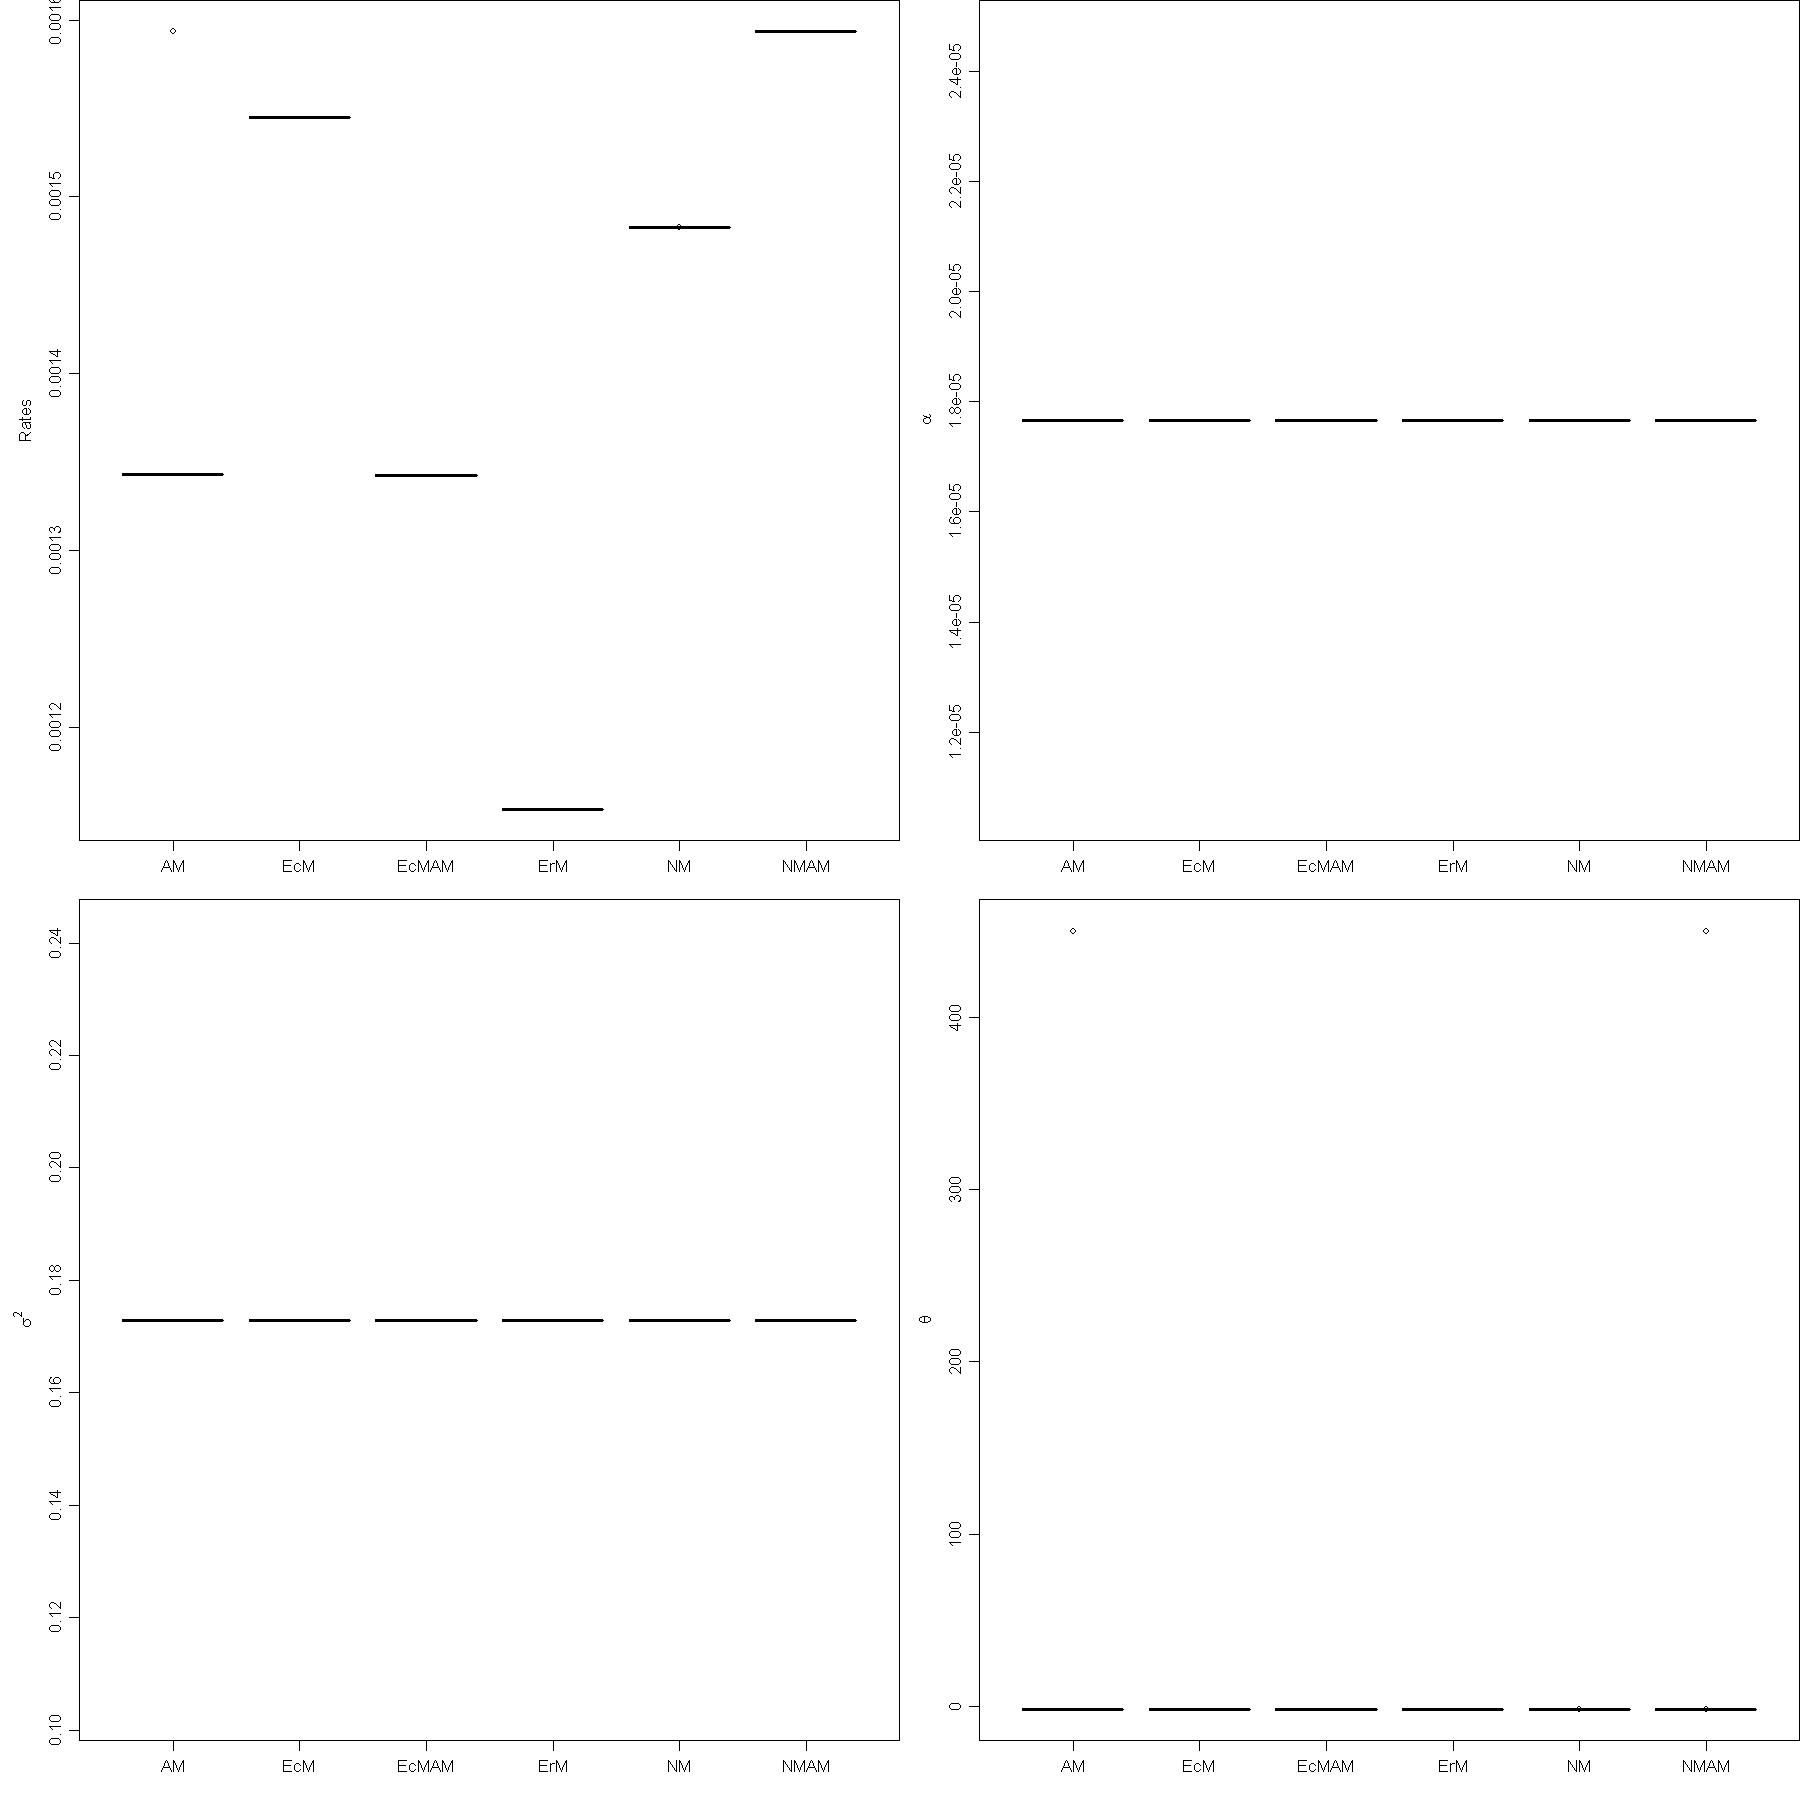

In [28]:
plot_model_averages(data = avg_rd_1301_cid)

## ___2. 1292 species, 5 mycorrhizal states and FRED 4.0___
------------------------------

In [26]:
# post removal of the taxonomically conserved mycorrhizal states;
# Ericoid mycorrhizal species were removed 
# the subset had no Orchidaceous mycorrhizae, to begin with

In [22]:
#-----------------
# root diameter
#-----------------

rd_1292_cd <- read_all_rds(dirpath = "./../../data/chapter2/rdata/parallel/rd_1292_100sims/", cd = TRUE, strip = "F00679_CD")
rd_1292_cid <- read_all_rds(dirpath = "./../../data/chapter2/rdata/parallel/rd_1292_100sims/", cd = FALSE, strip = "F00679_CID")

In [23]:
OUwie::getModelTable(rd_1292_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,27,-123255.19,-199.9815,-123051.35,246565.58,171311.57,0
ARDOUMA,31,-37595.22,-212.9464,-85496.09,75254.01,0.00,1
ARDOUMV,31,-123200.67,-201.5091,-122994.18,246464.92,171210.91,0
ARDOUMVA,35,-75886.77,-213.1033,-119266.61,151845.54,76591.53,0
EROUM,8,-84491.61,-214.8045,-84269.55,168999.34,93745.33,0
EROUMA,12,-56168.96,-312.9568,-62871.31,112362.17,37108.16,0
EROUMV,12,-84469.78,-213.2868,-88710.85,168963.80,93709.79,0
EROUMVA,16,-138386.88,-290.6309,-262661.63,276806.18,201552.17,0
SYMOUM,17,-83659.46,-228.0067,-84604.96,167353.40,92099.39,0


In [24]:
convergence_failures(rd_1292_cd) # 9 out of 12 models failed????

[1] "ARDOUMA"  "ARDOUMVA" "EROUM"    "EROUMA"   "EROUMV"   "SYMOUM"   "SYMOUMA" 
[8] "SYMOUMV"  "SYMOUMVA"

In [25]:
OUwie::getModelTable(rd_1292_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,46,-123339.09,-238.2385,-123106.26,246773.64,171878.205,0.00000e+00
ARDOUMA,47,-37398.91,-237.7157,-73891.25,74895.44,0.000,1.00000e+00
ARDOUMV,47,-123225.33,-240.3728,-123045.39,246548.30,171652.858,0.00000e+00
ARDOUMVA,48,-42185.72,-233.2167,-77384.77,84471.21,9575.776,0.00000e+00
EROUM,8,-119511.54,-212.6618,-119294.68,239039.19,164143.753,0.00000e+00
EROUMA,9,-54116.83,-216.7180,-123160.76,108251.79,33356.352,0.00000e+00
EROUMV,9,-121872.62,-217.0078,-192994.76,243763.39,168867.949,0.00000e+00
EROUMVA,10,-38091.88,-217.0274,-101643.34,76203.92,1308.483,7.35294e-285
SYMOUM,26,-78771.41,-223.6261,-83659.39,157595.93,82700.489,0.00000e+00


In [26]:
convergence_failures(rd_1292_cid) # that's 6 out of 12 models

[1] "ARDOUMA"  "ARDOUMVA" "EROUMA"   "EROUMVA"  "SYMOUMA"  "SYMOUMVA"

In [41]:
capture.output(avg_rd_1292_cd <- OUwie::getModelAvgParams(rd_1292_cd, type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_rd_1292_cid <- OUwie::getModelAvgParams(rd_1292_cid, type = "AICc", force = FALSE), file = nullfile())

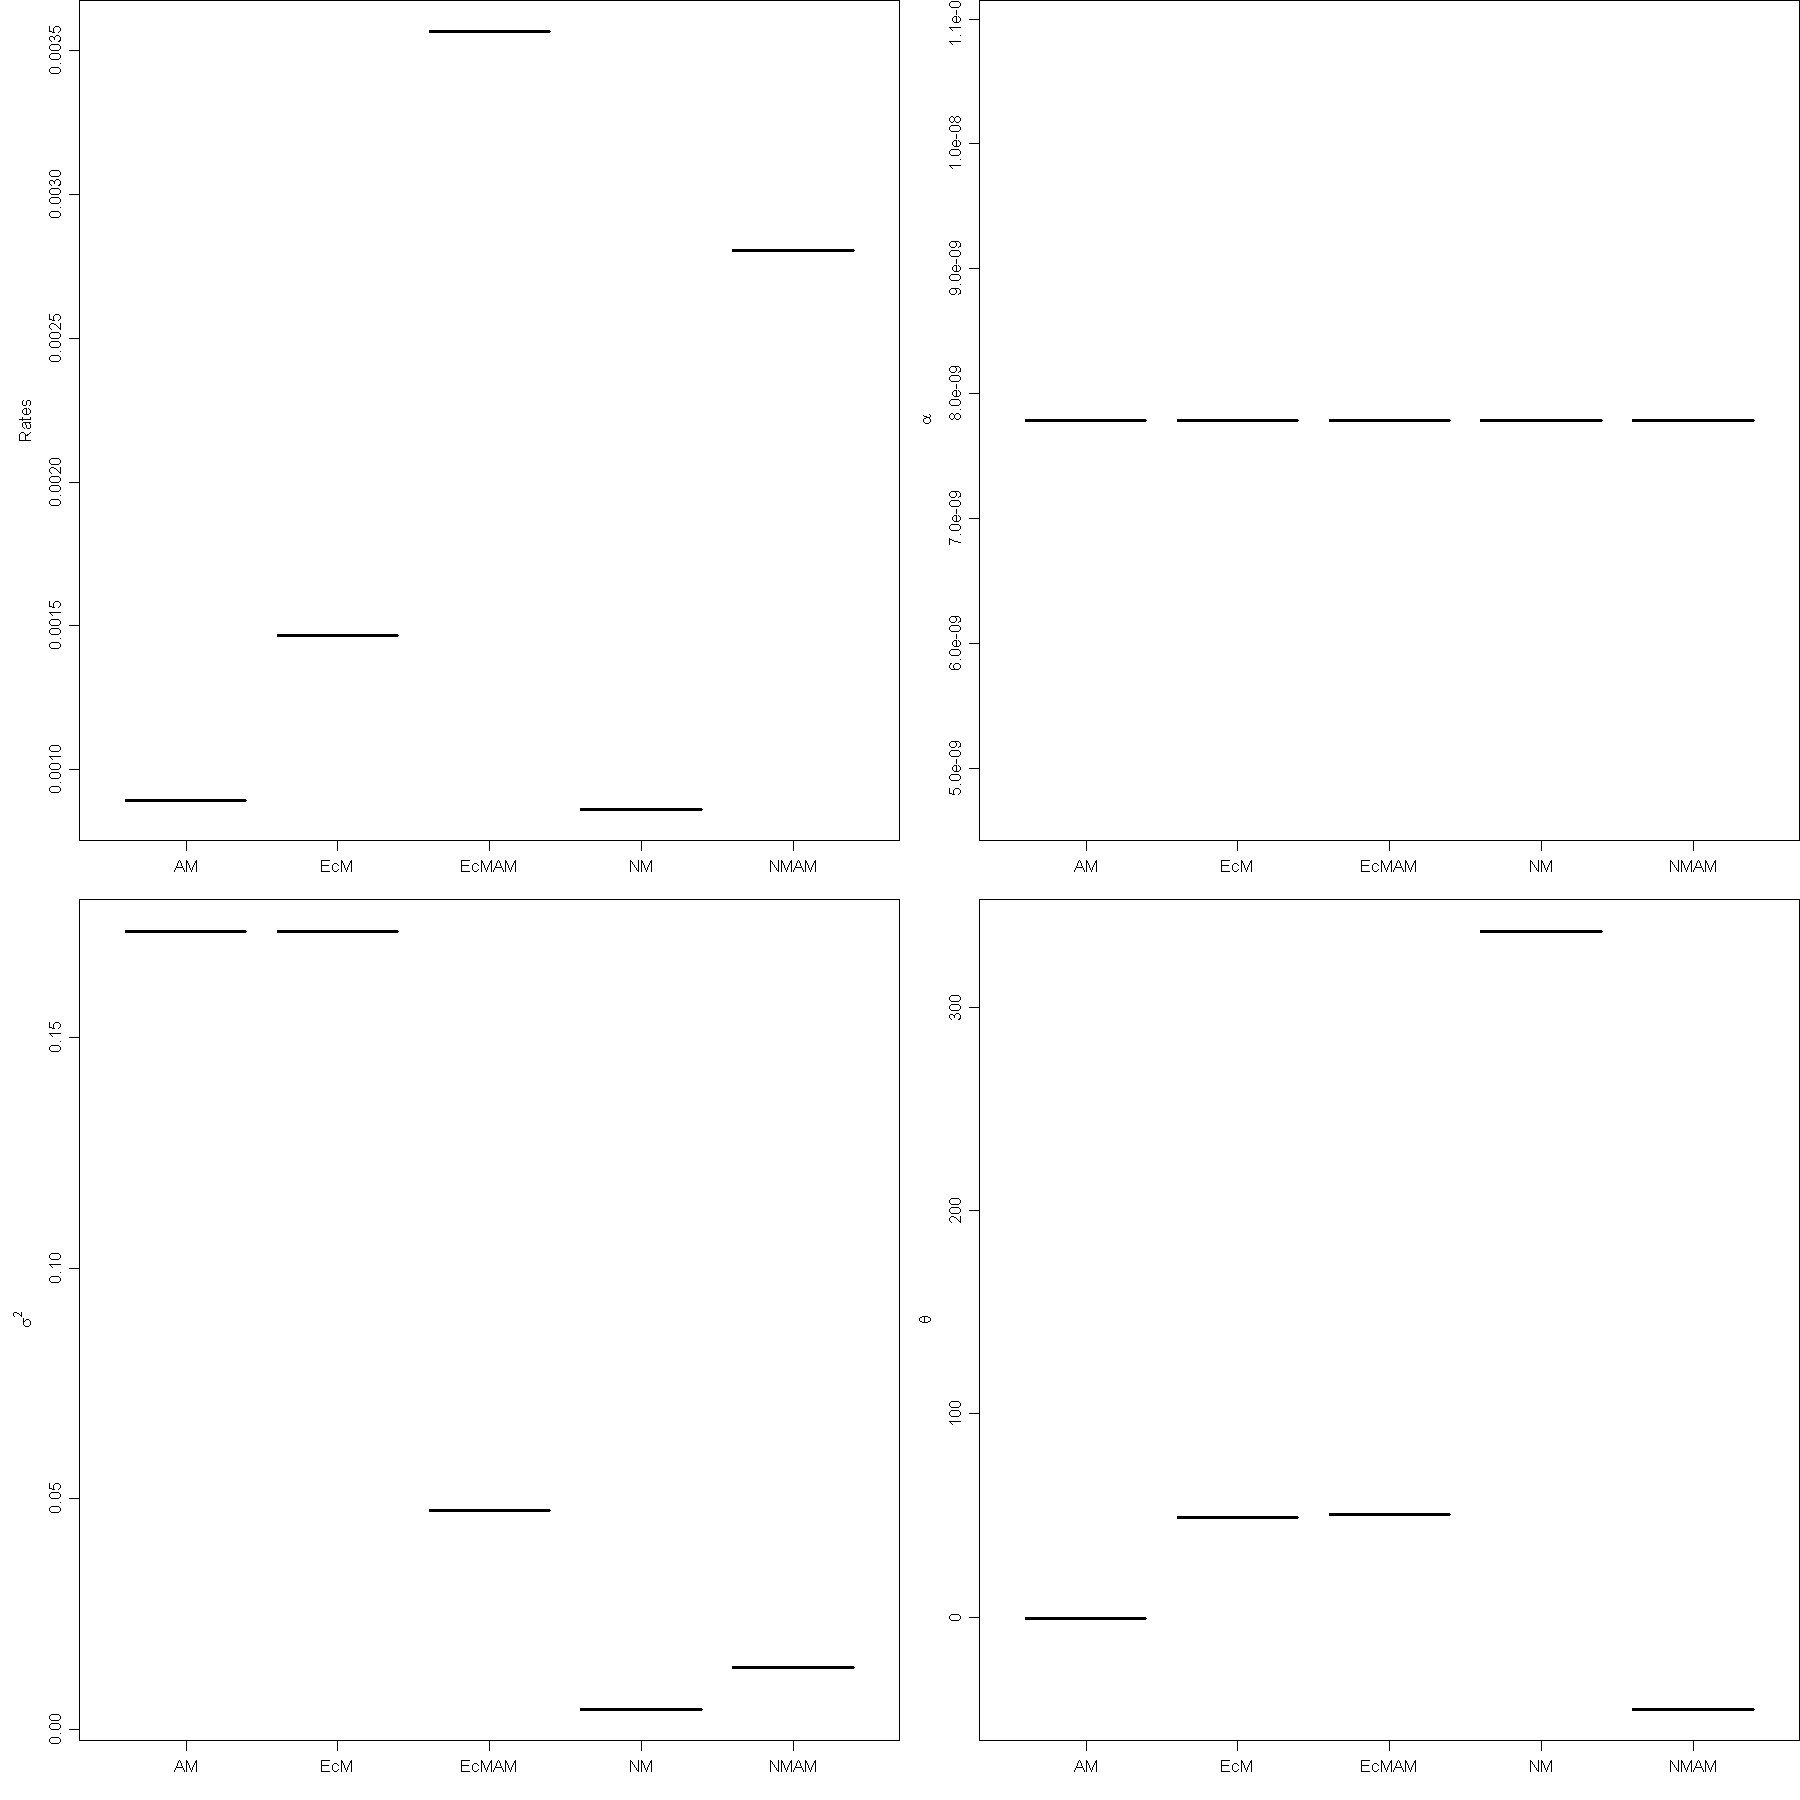

In [42]:
plot_model_averages(data = avg_rd_1292_cd)

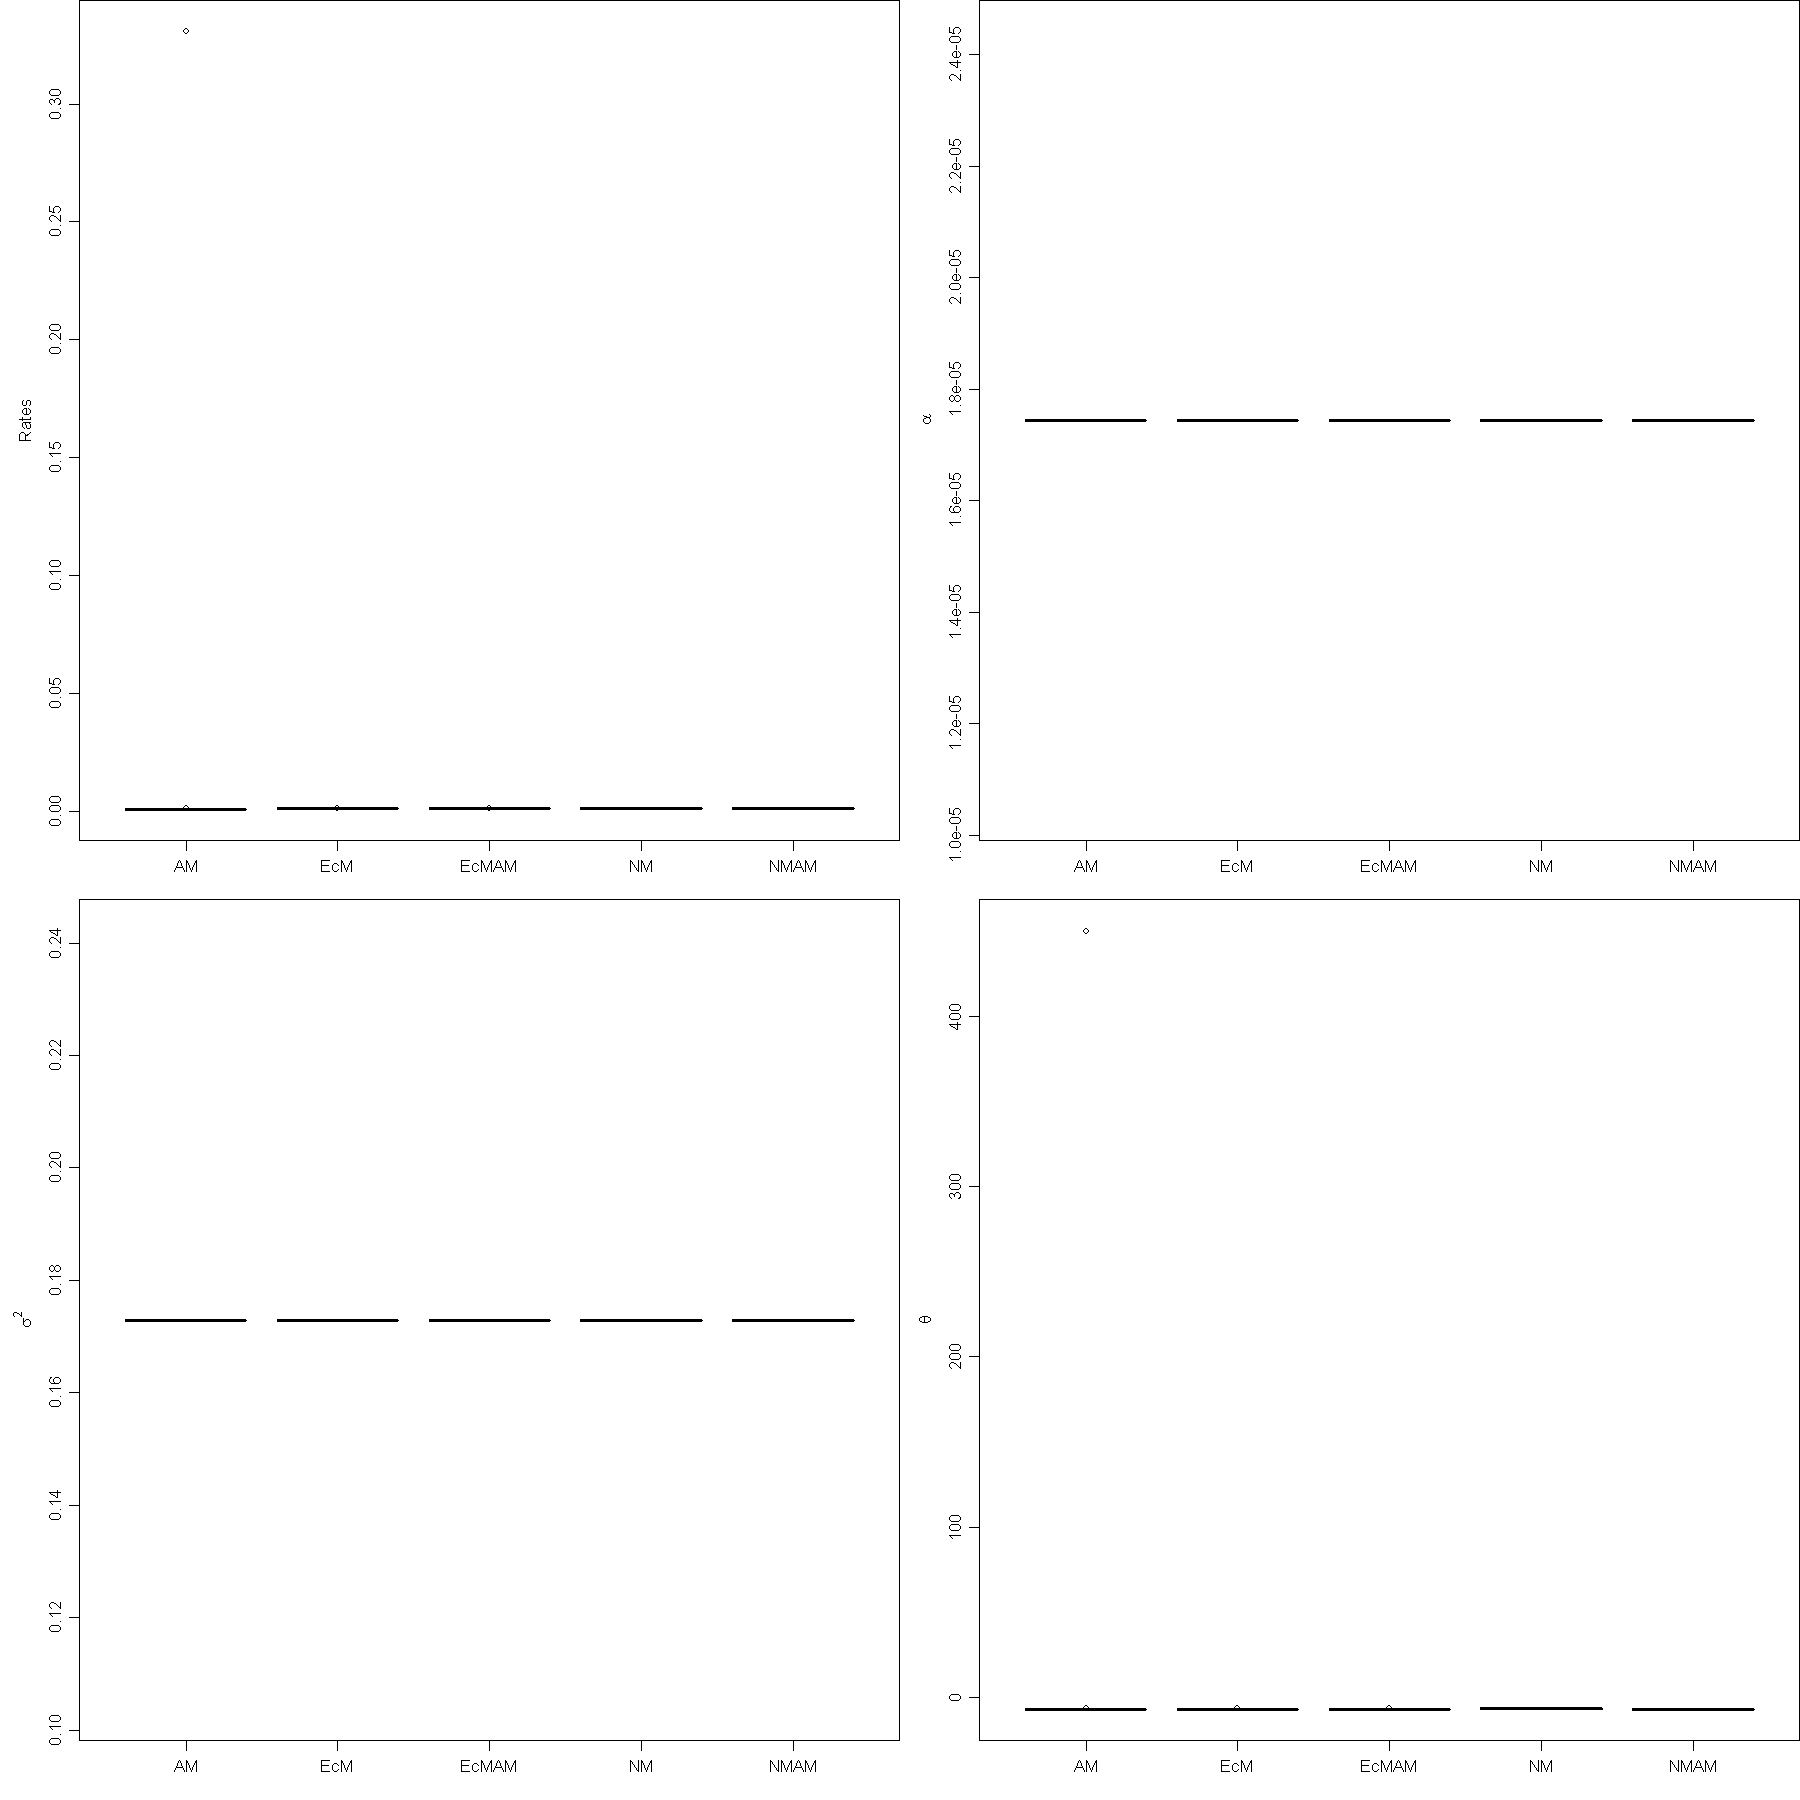

In [43]:
plot_model_averages(data = avg_rd_1292_cid)